# Analiza Sieci Steam
Poniższy notatnik wczytuje i analizuje dane z plików `edges.csv` oraz `nodes.csv`.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Wczytanie danych
print("Wczytywanie danych...")
edges_df = pd.read_csv('data/edges.csv')
nodes_df = pd.read_csv('data/nodes.csv')

print("Kształt danych edges:", edges_df.shape)
print("Kształt danych nodes:", nodes_df.shape)

display(edges_df.head())
display(nodes_df.head())

Wczytywanie danych...
Kształt danych edges: (459661, 4)
Kształt danych nodes: (267584, 2)


,source,target,type,weight
0,76561198105161290,App_400,game,326.0
1,76561198105161290,App_620,game,703.0
2,76561198105161290,App_730,game,31984.0
3,76561198105161290,App_3910,game,0.0
4,76561198105161290,App_4000,game,631.0


,id,node_type
0,76561198105161290,user
1,App_400,game
2,App_620,game
3,App_730,game
4,App_3910,game


In [2]:
# Sprawdzenie typów w węzłach i krawędziach
print("Typy węzłów:", nodes_df['node_type'].value_counts().to_dict())
print("\nTypy krawędzi:", edges_df['type'].value_counts().to_dict())

Typy węzłów: {'user': 232332, 'game': 35252}

Typy krawędzi: {'friend': 265754, 'game': 193907}


In [3]:
# Tworzenie grafu (skierowanego lub nieskierowanego)
# Ponieważ relacje 'friend' są zwykle nieskierowane, używamy nx.Graph, a posiadanie gry to dwudzielny graf.
G = nx.from_pandas_edgelist(edges_df, source='source', target='target', edge_attr=['type', 'weight'], create_using=nx.Graph())

print(f"Liczba węzłów grafu: {G.number_of_nodes()}")
print(f"Liczba krawędzi grafu: {G.number_of_edges()}")

Liczba węzłów grafu: 270623
Liczba krawędzi grafu: 459661


In [4]:
# Podgląd stopni węzłów (degree)
degrees = [deg for node, deg in G.degree()]
pd.Series(degrees).describe()

count    270623.000000
mean          3.397058
std          77.119984
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max       33026.000000
dtype: float64

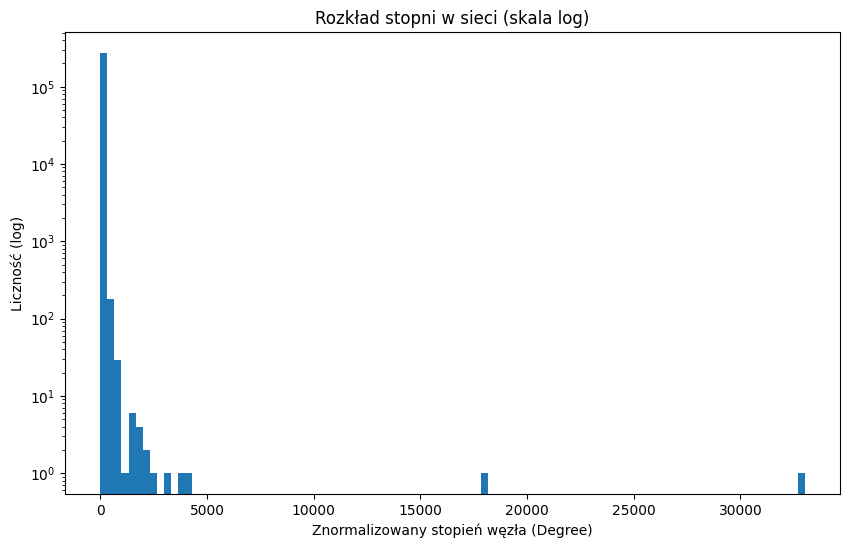

In [5]:
# Histogram rozkładu stopni (skala log-log ze względu na typowy rozkład potęgowy)
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=100, log=True)
plt.title('Rozkład stopni w sieci (skala log)')
plt.xlabel('Znormalizowany stopień węzła (Degree)')
plt.ylabel('Liczność (log)')
plt.show()

## Relacje Użytkowników z Grami
Analiza ilu użytkowników posiada przypisane gry (typ krawędzi = 'game'), a ilu nie ma ich w ogóle powiązanych w sieci.

Całkowita liczba użytkowników: 232332
Użytkownicy posiadający chociaż 1 grę: 1594
Użytkownicy z 0 grami w sieci: 230738


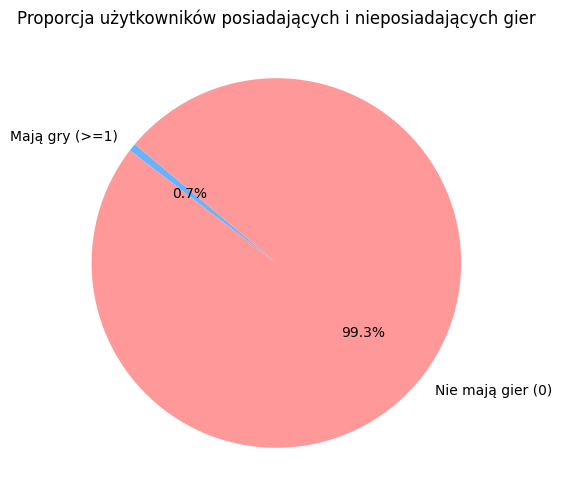

In [6]:
# Wyodrębnienie tylko krawędzi dotyczących gier
game_edges = edges_df[edges_df['type'] == 'game']

# Policzenie unikalnych użytkowników mających relacje z grami
users_with_games = game_edges['source'].nunique()

# Całkowita liczba użytkowników w węzłach
total_users = (nodes_df['node_type'] == 'user').sum()

# Obliczenie
users_without_games = total_users - users_with_games

print(f"Całkowita liczba użytkowników: {total_users}")
print(f"Użytkownicy posiadający chociaż 1 grę: {users_with_games}")
print(f"Użytkownicy z 0 grami w sieci: {users_without_games}")

# Wykres kołowy dla zobrazowania proporcji
plt.figure(figsize=(6, 6))
plt.pie(
    [users_with_games, users_without_games], 
    labels=['Mają gry (>=1)', 'Nie mają gier (0)'], 
    autopct='%1.1f%%', 
    startangle=140,
    colors=['#66b3ff', '#ff9999']
)
plt.title('Proporcja użytkowników posiadających i nieposiadających gier')
plt.show()

## Rzutowanie (Projekcja) Sieci - Sposób B
Ominięcie problemu graczy bez gier. Stworzymy sieć jednowarstwową złożoną **wyłącznie z gier**.
Dwie gry będą połączone krawędzią, jeśli jakiś gracz posiada obie gry na swoim profilu. Im więcej wspólnych graczy podzielą dwie gry, tym silniejsza (cięższa) będzie między nimi krawędź.
Nie musimy niczego na nowo zeskrapować - moduł `bipartite` z biblioteki `networkx` pozwala wyciągnąć to bezpośrednio z grafu relacji `users-games` za pomocą tzw. projekcji jednodzielnej!


Przygotowywanie grafu dwudzielnego (Bipartite Graph)...
Odrzucono kolekcjonerów. Wyliczanie relacji między samymi grami...

-> Ilość unikalnych gier w nowej sieci z graczami: 9210
-> Liczba krawędzi: 4015600

Top 10 najczęstszych dubletów Gier (najsilniejsze powiązania):
 - App_730 oraz App_218620 | wspólnych graczy: 657
 - App_730 oraz App_227300 | wspólnych graczy: 545
 - App_730 oraz App_304930 | wspólnych graczy: 520
 - App_730 oraz App_550 | wspólnych graczy: 498
 - App_730 oraz App_945360 | wspólnych graczy: 480
 - App_730 oraz App_4000 | wspólnych graczy: 474
 - App_346110 oraz App_407530 | wspólnych graczy: 449
 - App_730 oraz App_407530 | wspólnych graczy: 432
 - App_271590 oraz App_3240220 | wspólnych graczy: 422
 - App_730 oraz App_242760 | wspólnych graczy: 416


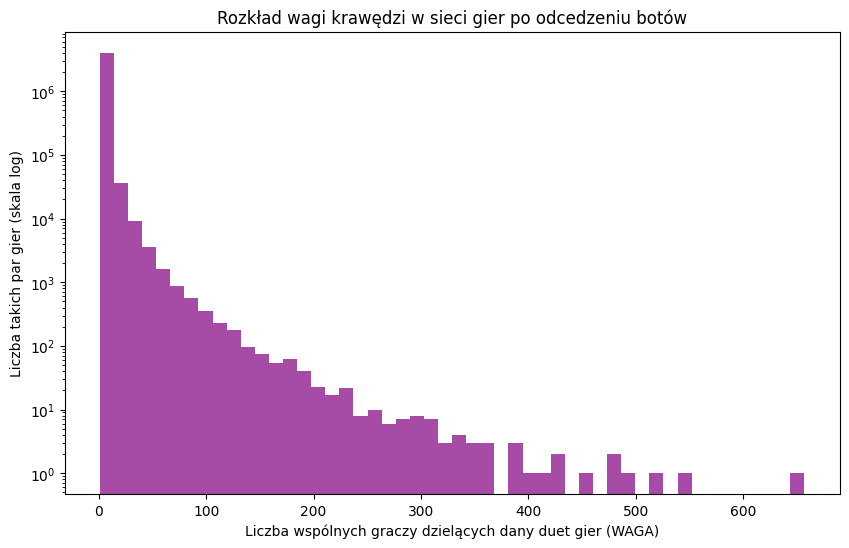

In [7]:
from networkx.algorithms import bipartite

print("Przygotowywanie grafu dwudzielnego (Bipartite Graph)...")

# UWAGA: Częsty problem w realnych sieciach! 
# Niektórzy użytkownicy (tzw. "kolekcjonerzy" lub boty) posiadają po 30 000 gier.
# Skrypt w networkx próbując połączyć ze sobą każde dwie gry takiego użytkownika 
# tworzy 500 milionów kombinacji krawędzi dla jednej osoby! To zawiesza program.
# Rozwiązanie: Filtrujemy "zwykłych" graczy (np. tych mających max 500 gier)
gra_count_per_user = game_edges.groupby('source').size()
normal_users = gra_count_per_user[gra_count_per_user <= 500].index

# Zostawiamy tylko krawędzie użytkowników mających do 500 gier
filtered_game_edges = game_edges[game_edges['source'].isin(normal_users)]

B = nx.Graph()

users = set(filtered_game_edges['source'].unique())
games = set(filtered_game_edges['target'].unique())

B.add_nodes_from(users, bipartite=0)
B.add_nodes_from(games, bipartite=1)

game_edges_list = list(zip(filtered_game_edges['source'], filtered_game_edges['target']))
B.add_edges_from(game_edges_list)

print(f"Odrzucono kolekcjonerów. Wyliczanie relacji między samymi grami...")
G_games = bipartite.weighted_projected_graph(B, games)

print(f"\n-> Ilość unikalnych gier w nowej sieci z graczami: {G_games.number_of_nodes()}")
print(f"-> Liczba krawędzi: {G_games.number_of_edges()}\n")

edges_with_weights = list(G_games.edges(data=True))
edges_with_weights.sort(key=lambda x: x[2]['weight'], reverse=True)

print("Top 10 najczęstszych dubletów Gier (najsilniejsze powiązania):")
for u, v, d in edges_with_weights[:10]:
    print(f" - {u} oraz {v} | wspólnych graczy: {d['weight']}")

import numpy as np
weights = [d['weight'] for u, v, d in edges_with_weights]
plt.figure(figsize=(10, 6))
plt.hist(weights, bins=50, log=True, color='purple', alpha=0.7)
plt.title('Rozkład wagi krawędzi w sieci gier po odcedzeniu botów')
plt.xlabel('Liczba wspólnych graczy dzielących dany duet gier (WAGA)')
plt.ylabel('Liczba takich par gier (skala log)')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# --- USTAWIENIA FILTRU ---
# Dobierz próg: rysujemy wycinek grafu, w którym gry mają minimum N wspólnych graczy
min_wspolnych_graczy = 3  

# Tworzymy podgraf składający się ze "znaczących" rzutowań (odcinamy szum np. pojedyńczych połączeń)
mocne_krawedzie = [
    (u, v) for u, v, d in G_games.edges(data=True) 
    if d['weight'] >= min_wspolnych_graczy
]

# Budujemy przefiltrowany graf
G_filtr = nx.Graph()
G_filtr.add_edges_from(mocne_krawedzie)

# Jeżeli graf nadal składa się z poszatkowanych wysp, do ładniejszej wizualizacji 
# wyciągamy z niego Największy Spójny Komponent (Giant Component)
if G_filtr.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G_filtr), key=len)
    G_plot = G_filtr.subgraph(largest_cc)
else:
    G_plot = G_filtr

print(f"Gotowe do rysowania: {G_plot.number_of_nodes()} węzłów gier i {G_plot.number_of_edges()} linii powiązań.")

# --- RYSOWANIE GRAFU ---
plt.figure(figsize=(14, 10))

# Layout Spring - działa jak fizyczne sprężyny (najbardziej odpycha niepołączone węzły)
# Możesz spróbować zmienić k=0.1 na k=0.5 żeby zobaczyć jak się oddalają
pos = nx.spring_layout(G_plot, k=0.2, iterations=35, seed=42)

# Uzależnienie średnicy rysowanej kropki-węzła od potęgi (stopnia relacji) danej gry w wycinku
degrees = dict(G_plot.degree())
node_sizes = [v * 12 for v in degrees.values()]

# 1. Rysuj cienkie linie krawędzi
nx.draw_networkx_edges(G_plot, pos, alpha=0.3, edge_color="gray")

# 2. Rysuj węzły gier
nx.draw_networkx_nodes(
    G_plot, pos, 
    node_size=node_sizes, 
    node_color="#ff7f50", # koralowy pomarańcz 
    alpha=0.9, 
    edgecolors="white"
)

# 3. Dodanie podpisów (Labels) TYLKO dla 15 najbardziej połączonych gier, żeby ukryć chaos
top_nodes = sorted(degrees.items(), key=lambda z: z[1], reverse=True)[:15]
labels = {node_id: node_id for node_id, _ in top_nodes}

nx.draw_networkx_labels(
    G_plot, pos, 
    labels=labels, 
    font_size=9, 
    font_weight="bold", 
    font_color="black",
    verticalalignment="bottom"
)

plt.title(f"Rozkład społeczności Gier na Steam (min. łączących graczy: {min_wspolnych_graczy})", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()
